# Dataset Class And Annotation Analysis

This notebook calculates the number of annotations for each class in the dataset and visualizes how many annotations each image contains.

In [2]:
pip install -r requirements.txt

  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached iniconfig-2.3.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached numpy-2.4.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached packaging-26.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.1.1-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached platformdirs-4.9.6-py3-none-any.whl.metadata (4.7 kB)
  Using cached pluggy-1.6.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached polars-1.40.0-py3-none-any.whl.metadata (10 kB)
  Using cached polars_runtime_32-1.40.0-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
  Using cached pytest-9.0.3-py3-none-any.whl.metadata (7.6 kB)
  Using cached setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python >=3.9,<3.13; 1.26.1 Requires-Python >=3.9,<3.13
ERROR: Could not find a version that satisfies the requirement torch==2.11.0+cu130 (from versions: 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch==2.11.0+cu130


In [3]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

print("Matplotlib backend:", matplotlib.get_backend())

Matplotlib backend: inline


In [6]:
from collections import Counter
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def resolve_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "medical_detection").exists():
            return candidate
    raise FileNotFoundError("Could not locate a project root containing the medical_detection package.")


PROJECT_ROOT = resolve_project_root(Path.cwd())
image_dir = PROJECT_ROOT / "SEE_AI_project_all_images" / "SEE_AI_project_all_images"
label_dir = PROJECT_ROOT / "SEE_AI_project_all_txt" / "SEE_AI_project_all_txt"
csv_path = PROJECT_ROOT / "all_annotation.csv"


def load_class_names(csv_path: Path) -> list[str]:
    class_mapping = {}
    with csv_path.open("r", encoding="utf-8") as handle:
        reader = csv.reader(handle)
        class_names_row = next(reader)
        class_ids_row = next(reader)
        for name, class_id_str in zip(class_names_row, class_ids_row):
            value = class_id_str.strip()
            if value.isdigit():
                class_mapping[int(value)] = name.strip()
    max_class_id = max(class_mapping)
    return [class_mapping.get(index, f"missing_class_{index}") for index in range(max_class_id + 1)]


def load_records(image_dir: Path, label_dir: Path):
    records = []
    image_paths = []
    for pattern in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(sorted(image_dir.rglob(pattern)))

    for image_path in sorted(image_paths):
        label_path = label_dir / f"{image_path.stem}.txt"
        annotations = []
        if label_path.exists():
            for line in label_path.read_text(encoding="utf-8").splitlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id = int(float(parts[0]))
                x_center, y_center, width, height = map(float, parts[1:])
                if 0.0 <= x_center <= 1.0 and 0.0 <= y_center <= 1.0 and 0.0 < width <= 1.0 and 0.0 < height <= 1.0:
                    annotations.append(
                        {
                            "class_id": class_id,
                            "x_center": x_center,
                            "y_center": y_center,
                            "width": width,
                            "height": height,
                        }
                    )
        records.append({"image_path": image_path, "annotations": annotations})
    return records


class_names = load_class_names(csv_path)
records = load_records(image_dir, label_dir)
positive_records = [record for record in records if record["annotations"]]
negative_records = [record for record in records if not record["annotations"]]

print(f"Total images: {len(records)}")
print(f"Positive images: {len(positive_records)}")
print(f"Negative images: {len(negative_records)}")
print(f"Number of classes: {len(class_names)}")

Total images: 18481
Positive images: 12290
Negative images: 6191
Number of classes: 11


In [7]:
class_counts = Counter()
annotation_count_per_image = []

for record in records:
    annotation_count_per_image.append(len(record["annotations"]))
    for annotation in record["annotations"]:
        class_counts[annotation["class_id"]] += 1

class_distribution = pd.DataFrame(
    {
        "class_id": list(range(len(class_names))),
        "class_name": list(class_names),
        "annotation_count": [class_counts[class_id] for class_id in range(len(class_names))],
    }
).sort_values("annotation_count", ascending=False, ignore_index=True)

class_distribution

,class_id,class_name,annotation_count
0,4,lymph follicle,6788
1,1,erosion,5987
2,6,polyp-like,3230
3,9,foreign body,1646
4,8,erythema,1019
5,0,angiodysplasia,931
6,10,vein,914
7,7,bleeding,868
8,3,lymphangiectasia,608
9,5,SMT,542


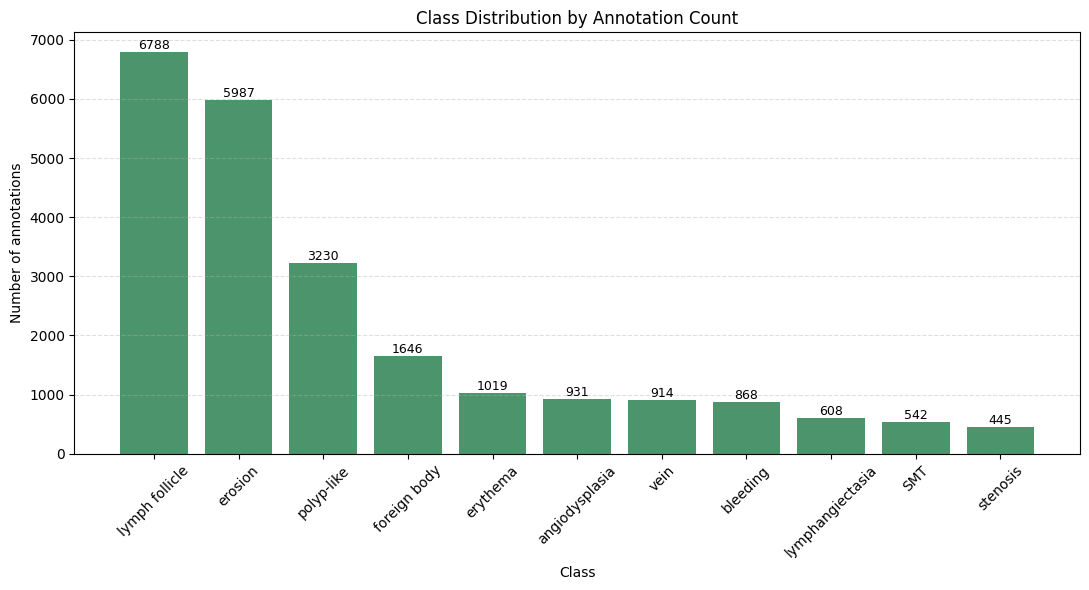

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(class_distribution["class_name"], class_distribution["annotation_count"], color="#4c956c")
ax.set_title("Class Distribution by Annotation Count")
ax.set_xlabel("Class")
ax.set_ylabel("Number of annotations")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


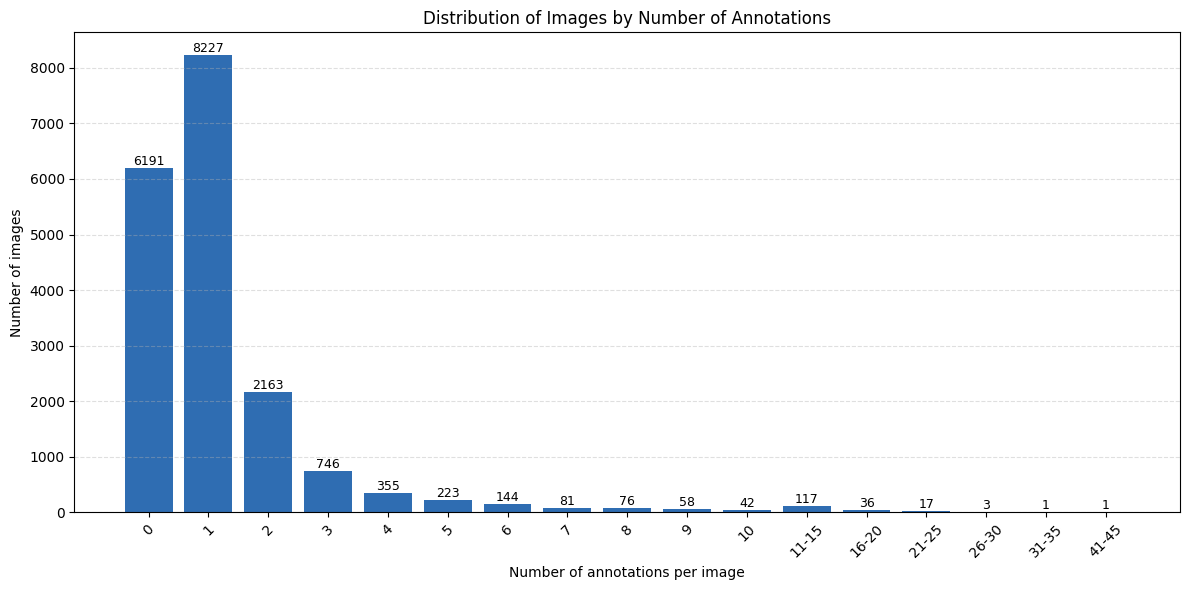

,annotation_group,image_count
0,0,6191
1,1,8227
2,2,2163
3,3,746
4,4,355
5,5,223
6,6,144
7,7,81
8,8,76
9,9,58


In [9]:
annotation_distribution = pd.Series(annotation_count_per_image).value_counts().sort_index()

grouped_distribution = []
for annotation_count, image_count in annotation_distribution.items():
    if annotation_count <= 10:
        label = str(annotation_count)
        sort_key = annotation_count
    else:
        lower = ((annotation_count - 11) // 5) * 5 + 11
        upper = lower + 4
        label = f"{lower}-{upper}"
        sort_key = lower
    grouped_distribution.append((sort_key, label, image_count))

grouped_distribution_df = pd.DataFrame(grouped_distribution, columns=["sort_key", "annotation_group", "image_count"])
grouped_distribution_df = grouped_distribution_df.groupby(["sort_key", "annotation_group"], as_index=False)["image_count"].sum()
grouped_distribution_df = grouped_distribution_df.sort_values("sort_key", ignore_index=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(grouped_distribution_df["annotation_group"], grouped_distribution_df["image_count"], color="#2f6db2")
ax.set_title("Distribution of Images by Number of Annotations")
ax.set_xlabel("Number of annotations per image")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{int(height)}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
plt.close(fig)

grouped_distribution_df[["annotation_group", "image_count"]]


In [10]:
import json
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader
from torchmetrics.detection import MeanAveragePrecision
from torchvision.ops import box_iou
from ultralytics import YOLO

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from medical_detection import (
    FRCNNDataset,
    FRCNNDatasetConfig,
    ProjectPaths,
    build_dataset_index,
    build_faster_rcnn_model,
    class_names_from_csv,
    collate_fn,
    convert_yolo_to_xyxy,
    load_split_filenames,
    materialize_yolo_dataset,
    records_from_filenames,
    resolve_dataset_root,
    write_yolo_data_yaml,
)


def resolve_split_label(split_suffix: str) -> str:
    return split_suffix.lstrip("_") or "baseline"


def find_yolo_weights_for_split(project_root: Path, split_label: str) -> Path:
    detect_dir = project_root / "runs" / "detect"
    helper_path = detect_dir / "latest_yolo_run.txt"
    if split_label == "baseline" and helper_path.exists():
        run_dir = Path(helper_path.read_text(encoding="utf-8").strip())
        candidate = run_dir / "weights" / "best.pt"
        if candidate.exists():
            return candidate

    candidates = sorted(
        detect_dir.glob(f"*{split_label}*/weights/best.pt"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No YOLO weights found for split label '{split_label}'.")
    return candidates[0]


def find_frcnn_checkpoint_for_split(project_root: Path, split_label: str) -> Path:
    checkpoint_dir = project_root / "runs" / ("frcnn" if split_label == "baseline" else f"frcnn_{split_label}")
    preferred = checkpoint_dir / "faster_rcnn_best.pth"
    if preferred.exists():
        return preferred

    candidates = sorted(checkpoint_dir.glob("*.pth"), key=lambda path: path.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError(f"No Faster R-CNN checkpoint found for split label '{split_label}'.")
    return candidates[0]


def build_ground_truth_tensors(record, class_names):
    with Image.open(record.image_path) as image_handle:
        image_width, image_height = image_handle.size

    boxes = []
    labels = []
    for ann in record.annotations:
        box = convert_yolo_to_xyxy(ann.x_center, ann.y_center, ann.width, ann.height, image_width, image_height)
        boxes.append([box.xmin, box.ymin, box.xmax, box.ymax])
        labels.append(ann.class_id)

    if boxes:
        box_tensor = torch.tensor(boxes, dtype=torch.float32)
        label_tensor = torch.tensor(labels, dtype=torch.int64)
    else:
        box_tensor = torch.zeros((0, 4), dtype=torch.float32)
        label_tensor = torch.zeros((0,), dtype=torch.int64)
    return box_tensor, label_tensor


def match_detections(pred_boxes, pred_labels, gt_boxes, gt_labels, num_classes, iou_threshold=0.5):
    background_index = num_classes
    confusion = torch.zeros((num_classes + 1, num_classes + 1), dtype=torch.int64)
    counters = Counter(
        {
            "correct_matches": 0,
            "wrong_class_matches": 0,
            "duplicate_detections": 0,
            "localization_false_positives": 0,
            "background_false_positives": 0,
            "localization_false_negatives": 0,
            "missed_ground_truths": 0,
        }
    )
    matched_ious = []
    matched_preds = set()
    matched_gts = set()

    if pred_boxes.numel() and gt_boxes.numel():
        iou_matrix = box_iou(pred_boxes, gt_boxes)
        candidate_pairs = []
        for pred_index in range(pred_boxes.shape[0]):
            for gt_index in range(gt_boxes.shape[0]):
                iou_value = float(iou_matrix[pred_index, gt_index].item())
                if iou_value >= iou_threshold:
                    candidate_pairs.append((iou_value, pred_index, gt_index))

        for iou_value, pred_index, gt_index in sorted(candidate_pairs, key=lambda item: item[0], reverse=True):
            if pred_index in matched_preds or gt_index in matched_gts:
                continue
            matched_preds.add(pred_index)
            matched_gts.add(gt_index)
            pred_label = int(pred_labels[pred_index].item())
            gt_label = int(gt_labels[gt_index].item())
            confusion[gt_label, pred_label] += 1
            matched_ious.append(iou_value)
            if pred_label == gt_label:
                counters["correct_matches"] += 1
            else:
                counters["wrong_class_matches"] += 1

    for pred_index in range(pred_boxes.shape[0]):
        if pred_index in matched_preds:
            continue

        pred_label = int(pred_labels[pred_index].item())
        confusion[background_index, pred_label] += 1

        if gt_boxes.numel():
            overlaps = box_iou(pred_boxes[pred_index : pred_index + 1], gt_boxes).squeeze(0)
            best_iou = float(overlaps.max().item()) if overlaps.numel() else 0.0
            duplicate_hit = any(
                int(gt_labels[gt_index].item()) == pred_label and float(overlaps[gt_index].item()) >= iou_threshold
                for gt_index in matched_gts
            )
            same_class_overlap = any(
                int(gt_labels[gt_index].item()) == pred_label and float(overlaps[gt_index].item()) > 0.0
                for gt_index in range(len(gt_labels))
            )

            if duplicate_hit:
                counters["duplicate_detections"] += 1
            elif same_class_overlap and best_iou > 0.0:
                counters["localization_false_positives"] += 1
            else:
                counters["background_false_positives"] += 1
        else:
            counters["background_false_positives"] += 1

    for gt_index in range(gt_boxes.shape[0]):
        if gt_index in matched_gts:
            continue

        gt_label = int(gt_labels[gt_index].item())
        confusion[gt_label, background_index] += 1

        if pred_boxes.numel():
            overlaps = box_iou(gt_boxes[gt_index : gt_index + 1], pred_boxes).squeeze(0)
            same_class_overlap = any(
                int(pred_labels[pred_index].item()) == gt_label and float(overlaps[pred_index].item()) > 0.0
                for pred_index in range(len(pred_labels))
            )
            if same_class_overlap:
                counters["localization_false_negatives"] += 1
            else:
                counters["missed_ground_truths"] += 1
        else:
            counters["missed_ground_truths"] += 1

    return confusion, counters, matched_ious


def summarize_confusion(confusion, class_names):
    num_classes = len(class_names)
    object_confusion = confusion[:num_classes, :num_classes]
    true_positives = int(torch.diag(object_confusion).sum().item())
    wrong_class = int((object_confusion.sum() - torch.diag(object_confusion).sum()).item())
    false_positives = int(confusion[num_classes, :num_classes].sum().item() + wrong_class)
    false_negatives = int(confusion[:num_classes, num_classes].sum().item() + wrong_class)
    precision = true_positives / max(true_positives + false_positives, 1)
    recall = true_positives / max(true_positives + false_negatives, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-12)

    return {
        "TP": true_positives,
        "FP": false_positives,
        "FN": false_negatives,
        "wrong_class_matches": wrong_class,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def classwise_error_table(confusion, class_names):
    rows = []
    num_classes = len(class_names)
    for class_index, class_name in enumerate(class_names):
        true_positive = int(confusion[class_index, class_index].item())
        false_positive = int(confusion[:, class_index].sum().item() - true_positive)
        false_negative = int(confusion[class_index, :].sum().item() - true_positive)
        precision = true_positive / max(true_positive + false_positive, 1)
        recall = true_positive / max(true_positive + false_negative, 1)
        f1 = (2 * precision * recall) / max(precision + recall, 1e-12)
        rows.append(
            {
                "class_name": class_name,
                "TP": true_positive,
                "FP": false_positive,
                "FN": false_negative,
                "precision": precision,
                "recall": recall,
                "f1": f1,
            }
        )
    return pd.DataFrame(rows).sort_values(["f1", "FN", "FP"], ascending=[True, False, False], ignore_index=True)


def plot_confusion_matrix(confusion, labels, title, normalize=False):
    matrix = confusion.detach().cpu().numpy().astype(float)
    if normalize:
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums > 0)

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Ground-truth class")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    for row_index in range(matrix.shape[0]):
        for col_index in range(matrix.shape[1]):
            value = matrix[row_index, col_index]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            ax.text(
                col_index,
                row_index,
                text,
                ha="center",
                va="center",
                color="white" if value > matrix.max() * 0.5 else "black",
                fontsize=9,
            )

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return None


def evaluate_prediction_set(predictions, references, class_names, model_name, iou_threshold=0.5):
    dataset_confusion = torch.zeros((len(class_names) + 1, len(class_names) + 1), dtype=torch.int64)
    dataset_counters = Counter()
    matched_ious = []
    image_rows = []

    for prediction, reference in zip(predictions, references):
        confusion, counters, image_ious = match_detections(
            prediction["boxes"],
            prediction["labels"],
            reference["boxes"],
            reference["labels"],
            num_classes=len(class_names),
            iou_threshold=iou_threshold,
        )
        dataset_confusion += confusion
        dataset_counters.update(counters)
        matched_ious.extend(image_ious)

        image_stats = summarize_confusion(confusion, class_names)
        image_rows.append(
            {
                "image_name": reference["image_name"],
                "TP": image_stats["TP"],
                "FP": image_stats["FP"],
                "FN": image_stats["FN"],
                "wrong_class_matches": image_stats["wrong_class_matches"],
                "duplicate_detections": counters["duplicate_detections"],
                "localization_false_positives": counters["localization_false_positives"],
                "localization_false_negatives": counters["localization_false_negatives"],
                "missed_ground_truths": counters["missed_ground_truths"],
            }
        )

    summary = summarize_confusion(dataset_confusion, class_names)
    summary_row = {
        "model": model_name,
        **summary,
        "duplicate_detections": int(dataset_counters["duplicate_detections"]),
        "localization_false_positives": int(dataset_counters["localization_false_positives"]),
        "background_false_positives": int(dataset_counters["background_false_positives"]),
        "localization_false_negatives": int(dataset_counters["localization_false_negatives"]),
        "missed_ground_truths": int(dataset_counters["missed_ground_truths"]),
        "mean_matched_iou": float(np.mean(matched_ious)) if matched_ious else 0.0,
    }

    hard_images = pd.DataFrame(image_rows).sort_values(
        ["FN", "FP", "wrong_class_matches", "image_name"],
        ascending=[False, False, False, True],
        ignore_index=True,
    )

    return {
        "summary": summary_row,
        "confusion": dataset_confusion,
        "class_table": classwise_error_table(dataset_confusion, class_names),
        "hard_images": hard_images,
    }


DATASET_ROOT = resolve_dataset_root(PROJECT_ROOT)
paths = ProjectPaths(project_root=PROJECT_ROOT, dataset_root=DATASET_ROOT)
class_names_eval = class_names_from_csv(paths.csv_path)
dataset_index = build_dataset_index(paths.image_dir, paths.label_dir, paths.csv_path, group_size=25)

YOLO_SPLIT_SUFFIX = ""
FRCNN_SPLIT_SUFFIX = ""
YOLO_SPLIT_LABEL = resolve_split_label(YOLO_SPLIT_SUFFIX)
FRCNN_SPLIT_LABEL = resolve_split_label(FRCNN_SPLIT_SUFFIX)
YOLO_CUSTOM_THRESHOLD = 0.5
FRCNN_CUSTOM_THRESHOLD = 0.5
MATCH_IOU_THRESHOLD = 0.5

YOLO_WORKING_DIR = paths.project_root / f"yolo_dataset_{YOLO_SPLIT_LABEL}"
YOLO_DATA_YAML = paths.project_root / f"data_live_{YOLO_SPLIT_LABEL}.yaml"

materialize_yolo_dataset(
    splits_dir=paths.splits_dir,
    image_dir=paths.image_dir,
    label_dir=paths.label_dir,
    output_dir=YOLO_WORKING_DIR,
)
YOLO_DATA_YAML = write_yolo_data_yaml(YOLO_WORKING_DIR, class_names_eval, YOLO_DATA_YAML)

test_records = records_from_filenames(dataset_index, load_split_filenames(paths.splits_dir / f"test{YOLO_SPLIT_SUFFIX}.txt"))
test_image_paths = [str(record.image_path) for record in test_records]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Evaluation device:", device)
print("Test images:", len(test_records))
print("YOLO weights:", find_yolo_weights_for_split(paths.project_root, YOLO_SPLIT_LABEL))
print("Faster R-CNN checkpoint:", find_frcnn_checkpoint_for_split(paths.project_root, FRCNN_SPLIT_LABEL))

Evaluation device: cpu
Test images: 1850
YOLO weights: z:\Zavrsni rad\FInishedProject\runs\detect\lesion_yolov8s_640_baseline\weights\best.pt
Faster R-CNN checkpoint: z:\Zavrsni rad\FInishedProject\runs\frcnn\faster_rcnn_best.pth


In [11]:
def plot_confusion_matrix(confusion, labels, title, normalize=False):
    matrix = confusion.detach().cpu().numpy().astype(float)
    if normalize:
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums > 0)

    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Ground-truth class")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    for row_index in range(matrix.shape[0]):
        for col_index in range(matrix.shape[1]):
            value = matrix[row_index, col_index]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            ax.text(
                col_index,
                row_index,
                text,
                ha="center",
                va="center",
                color="white" if value > matrix.max() * 0.5 else "black",
                fontsize=9,
            )

    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return None

In [12]:
pip install pycocotools faster-coco-eval torchmetrics[detection] torchmetrics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
yolo_weights_path = find_yolo_weights_for_split(paths.project_root, YOLO_SPLIT_LABEL)
yolo_model = YOLO(str(yolo_weights_path))
yolo_val = yolo_model.val(data=str(YOLO_DATA_YAML), split="test", verbose=False)

yolo_predictions = []
yolo_references = []
for record in test_records:
    gt_boxes, gt_labels = build_ground_truth_tensors(record, class_names_eval)
    prediction = yolo_model.predict(
        source=str(record.image_path),
        conf=YOLO_CUSTOM_THRESHOLD,
        verbose=False,
        device=(0 if torch.cuda.is_available() else "cpu"),
    )[0]
    if prediction.boxes is not None and len(prediction.boxes) > 0:
        pred_boxes = prediction.boxes.xyxy.cpu()
        pred_labels = prediction.boxes.cls.cpu().to(torch.int64)
        pred_scores = prediction.boxes.conf.cpu()
    else:
        pred_boxes = torch.zeros((0, 4), dtype=torch.float32)
        pred_labels = torch.zeros((0,), dtype=torch.int64)
        pred_scores = torch.zeros((0,), dtype=torch.float32)
    yolo_predictions.append({"boxes": pred_boxes, "labels": pred_labels, "scores": pred_scores})
    yolo_references.append({"boxes": gt_boxes, "labels": gt_labels, "image_name": record.image_path.name})

frcnn_records = records_from_filenames(dataset_index, load_split_filenames(paths.splits_dir / f"test{FRCNN_SPLIT_SUFFIX}.txt"))
frcnn_dataset = FRCNNDataset(frcnn_records, FRCNNDatasetConfig(include_empty_images=True, train=False))
frcnn_dataloader = DataLoader(
    frcnn_dataset,
    batch_size=2 if torch.cuda.is_available() else 1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

frcnn_checkpoint_path = find_frcnn_checkpoint_for_split(paths.project_root, FRCNN_SPLIT_LABEL)
frcnn_model = build_faster_rcnn_model(num_classes=len(class_names_eval) + 1, pretrained=False)
frcnn_model.load_state_dict(torch.load(frcnn_checkpoint_path, map_location=device)["model_state_dict"])
frcnn_model.to(device)
frcnn_model.eval()

frcnn_metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
frcnn_predictions = []
frcnn_references = []
record_offset = 0

with torch.no_grad():
    for images, targets in frcnn_dataloader:
        outputs = frcnn_model([image.to(device) for image in images])
        for output, target, record in zip(outputs, targets, frcnn_records[record_offset : record_offset + len(outputs)]):
            pred_mask = output["scores"].cpu() >= FRCNN_CUSTOM_THRESHOLD
            pred_boxes = output["boxes"].cpu()[pred_mask]
            pred_labels = output["labels"].cpu()[pred_mask].to(torch.int64) - 1
            pred_scores = output["scores"].cpu()[pred_mask]
            gt_boxes = target["boxes"].cpu()
            gt_labels = target["labels"].cpu().to(torch.int64) - 1

            frcnn_predictions.append({"boxes": pred_boxes, "labels": pred_labels, "scores": pred_scores})
            frcnn_references.append({"boxes": gt_boxes, "labels": gt_labels, "image_name": record.image_path.name})

            frcnn_metric.update(
                [{"boxes": pred_boxes, "scores": pred_scores, "labels": pred_labels + 1}],
                [{"boxes": gt_boxes, "labels": gt_labels + 1}],
            )
        record_offset += len(outputs)

frcnn_val = frcnn_metric.compute()

yolo_diagnostics = evaluate_prediction_set(
    yolo_predictions,
    yolo_references,
    class_names_eval,
    model_name="YOLOv8",
    iou_threshold=MATCH_IOU_THRESHOLD,
)
frcnn_diagnostics = evaluate_prediction_set(
    frcnn_predictions,
    frcnn_references,
    class_names_eval,
    model_name="Faster R-CNN",
    iou_threshold=MATCH_IOU_THRESHOLD,
)

evaluation_summary = pd.DataFrame(
    [
        {
            **yolo_diagnostics["summary"],
            "mAP@0.5": float(yolo_val.box.map50),
            "mAP@0.5:0.95": float(yolo_val.box.map),
        },
        {
            **frcnn_diagnostics["summary"],
            "mAP@0.5": float(frcnn_val["map_50"].item()),
            "mAP@0.5:0.95": float(frcnn_val["map"].item()),
        },
    ]
)

metrics_dir = paths.runs_dir / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)
evaluation_summary.to_csv(metrics_dir / "extended_model_error_summary.csv", index=False)

evaluation_summary

Ultralytics 8.4.35  Python-3.13.0 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600 6-Core Processor)
Model summary (fused): 93 layers, 25,846,129 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 124.570.8 MB/s, size: 64.3 KB)
val: Scanning Z:\Zavrsni rad\FInishedProject\yolo_dataset_baseline\labels\test... 1850 images, 505 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1850/1850 2.5Kit/s 0.7s0.0s
val: New cache created: Z:\Zavrsni rad\FInishedProject\yolo_dataset_baseline\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 116/116 4.0s/it 7:414.0ss
                   all       1850       2757      0.588      0.585      0.581       0.31
Speed: 1.0ms preprocess, 243.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to D:\OSIRV_Projekt\model-comparison-for-lesion-detection\runs\detect\val7


,model,TP,FP,FN,wrong_class_matches,precision,recall,f1,duplicate_detections,localization_false_positives,background_false_positives,localization_false_negatives,missed_ground_truths,mean_matched_iou,mAP@0.5,mAP@0.5:0.95
0,YOLOv8,999,256,1758,77,0.796016,0.36235,0.498006,20,84,75,312,1369,0.771392,0.580781,0.310026
1,Faster R-CNN,1585,1369,1172,204,0.536561,0.57490,0.555069,66,445,654,455,513,0.740907,0.459071,0.228306


Extended evaluation summary


,model,mAP@0.5,mAP@0.5:0.95,TP,FP,FN,wrong_class_matches,duplicate_detections,localization_false_positives,background_false_positives,localization_false_negatives,missed_ground_truths,precision,recall,f1,mean_matched_iou
0,YOLOv8,0.5808,0.3100,999,256,1758,77,20,84,75,312,1369,0.7960,0.3624,0.4980,0.7714
1,Faster R-CNN,0.4591,0.2283,1585,1369,1172,204,66,445,654,455,513,0.5366,0.5749,0.5551,0.7409


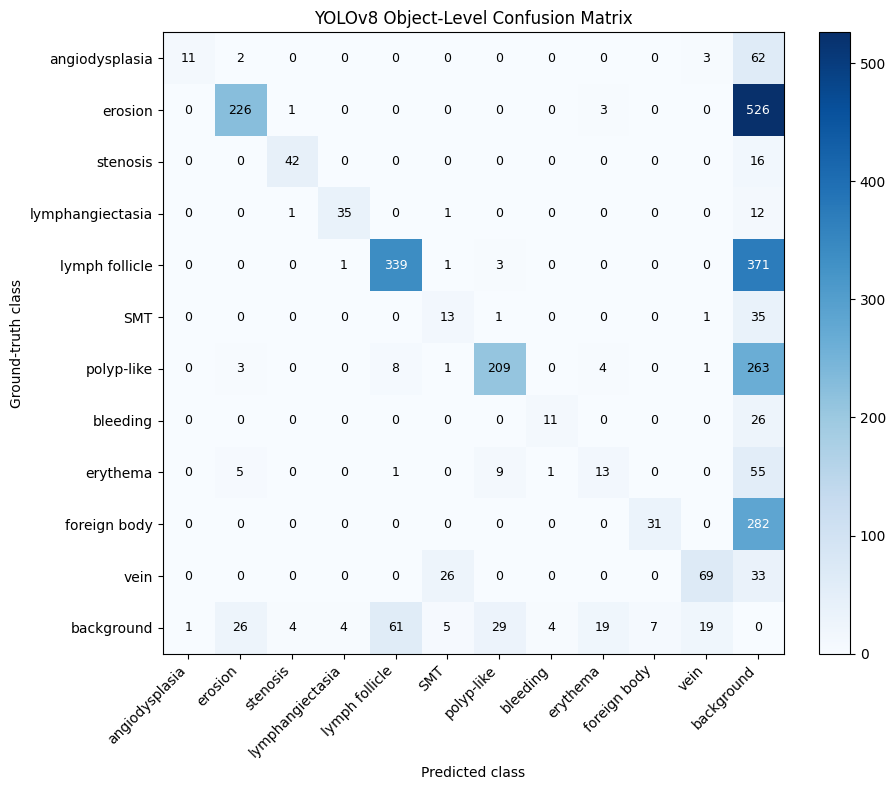

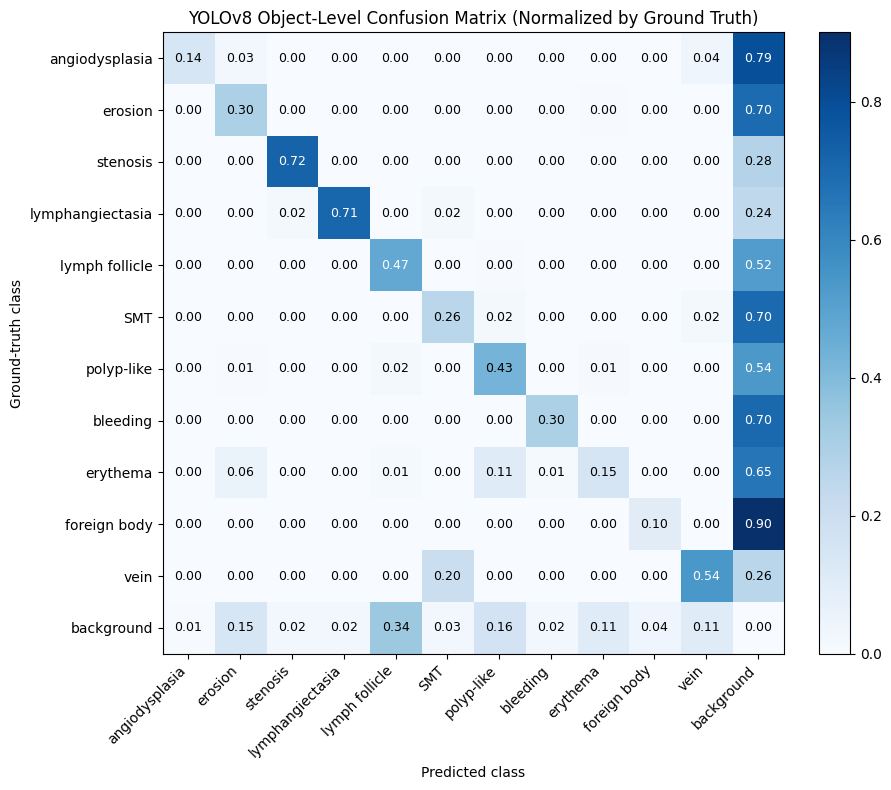

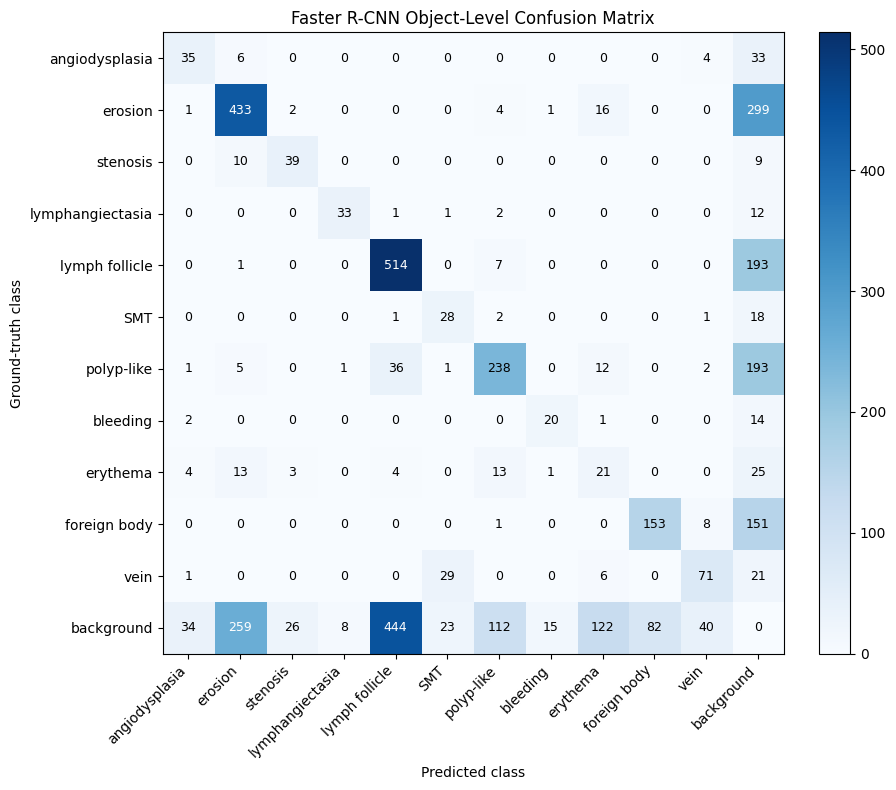

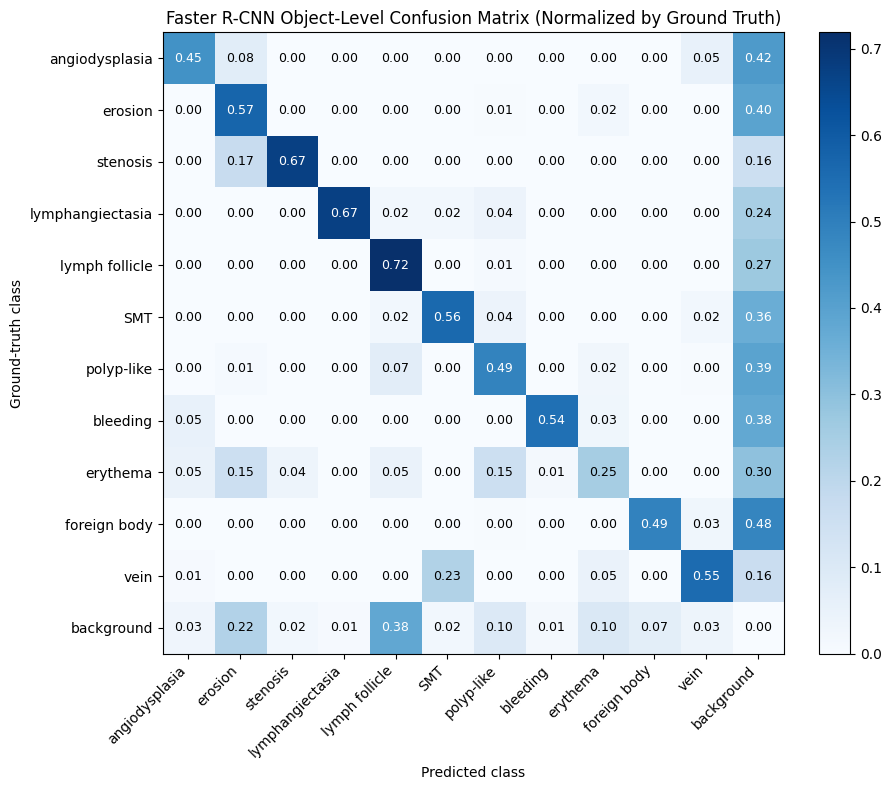

YOLOv8 classes ranked by F1 score (full table)


,class_name,TP,FP,FN,precision,recall,f1
0,foreign body,31,7,282,0.8158,0.0990,0.1766
1,erythema,13,26,71,0.3333,0.1548,0.2114
2,angiodysplasia,11,1,67,0.9167,0.1410,0.2444
3,SMT,13,34,37,0.2766,0.2600,0.2680
4,bleeding,11,5,26,0.6875,0.2973,0.4151
5,erosion,226,36,530,0.8626,0.2989,0.4440
6,polyp-like,209,42,280,0.8327,0.4274,0.5649
7,lymph follicle,339,70,376,0.8289,0.4741,0.6032
8,vein,69,24,59,0.7419,0.5391,0.6244
9,lymphangiectasia,35,5,14,0.8750,0.7143,0.7865


YOLOv8 lymphangiectasia row


,class_name,TP,FP,FN,precision,recall,f1
9,lymphangiectasia,35,5,14,0.875,0.7143,0.7865


Faster R-CNN classes ranked by F1 score (full table)


...

,class_name,TP,FP,FN,precision,recall,f1
10,lymphangiectasia,33,9,16,0.7857,0.6735,0.7253


YOLOv8 hardest test images


,image_name,TP,FP,FN,wrong_class_matches,duplicate_detections,localization_false_positives,localization_false_negatives,missed_ground_truths
0,image12164.jpg,0,1,23,0,0,1,22,1
1,image06843.jpg,1,0,19,0,0,0,2,17
2,image06842.jpg,0,0,16,0,0,0,0,16
3,image06841.jpg,1,0,14,0,0,0,3,11
4,image06840.jpg,3,1,13,0,0,1,4,9
...,...,...,...,...,...,...,...,...,...
1845,image18399.jpg,2,0,0,0,0,0,0,0
1846,image18451.jpg,0,0,0,0,0,0,0,0
1847,image18456.jpg,1,0,0,0,0,0,0,0
1848,image18458.jpg,1,0,0,0,0,0,0,0


Faster R-CNN hardest test images


,image_name,TP,FP,FN,wrong_class_matches,duplicate_detections,localization_false_positives,localization_false_negatives,missed_ground_truths
0,image12164.jpg,5,1,18,0,0,1,18,0
1,image05092.jpg,0,9,14,6,0,0,0,8
2,image06842.jpg,6,6,10,1,1,2,9,0
3,image06843.jpg,11,5,9,0,0,3,9,0
4,image06840.jpg,7,4,9,0,0,4,9,0
...,...,...,...,...,...,...,...,...,...
1845,image18393.jpg,1,0,0,0,0,0,0,0
1846,image18456.jpg,1,0,0,0,0,0,0,0
1847,image18457.jpg,1,0,0,0,0,0,0,0
1848,image18458.jpg,1,0,0,0,0,0,0,0


In [14]:
display_columns = [
    "model",
    "mAP@0.5",
    "mAP@0.5:0.95",
    "TP",
    "FP",
    "FN",
    "wrong_class_matches",
    "duplicate_detections",
    "localization_false_positives",
    "background_false_positives",
    "localization_false_negatives",
    "missed_ground_truths",
    "precision",
    "recall",
    "f1",
    "mean_matched_iou",
]

print("Extended evaluation summary")
display(evaluation_summary[display_columns].round(4))

background_label = "background"
all_confusion_labels = class_names_eval + [background_label]

plot_confusion_matrix(
    yolo_diagnostics["confusion"],
    all_confusion_labels,
    title="YOLOv8 Object-Level Confusion Matrix",
    normalize=False,
)
plot_confusion_matrix(
    yolo_diagnostics["confusion"],
    all_confusion_labels,
    title="YOLOv8 Object-Level Confusion Matrix (Normalized by Ground Truth)",
    normalize=True,
)

plot_confusion_matrix(
    frcnn_diagnostics["confusion"],
    all_confusion_labels,
    title="Faster R-CNN Object-Level Confusion Matrix",
    normalize=False,
)
plot_confusion_matrix(
    frcnn_diagnostics["confusion"],
    all_confusion_labels,
    title="Faster R-CNN Object-Level Confusion Matrix (Normalized by Ground Truth)",
    normalize=True,
)

print("YOLOv8 classes ranked by F1 score (full table)")
display(yolo_diagnostics["class_table"].round(4))

print("YOLOv8 lymphangiectasia row")
display(yolo_diagnostics["class_table"].query("class_name == 'lymphangiectasia'").round(4))

print("Faster R-CNN classes ranked by F1 score (full table)")
display(frcnn_diagnostics["class_table"].round(4))

print("Faster R-CNN lymphangiectasia row")
display(frcnn_diagnostics["class_table"].query("class_name == 'lymphangiectasia'").round(4))

print("YOLOv8 hardest test images")
display(yolo_diagnostics["hard_images"])

print("Faster R-CNN hardest test images")
display(frcnn_diagnostics["hard_images"])

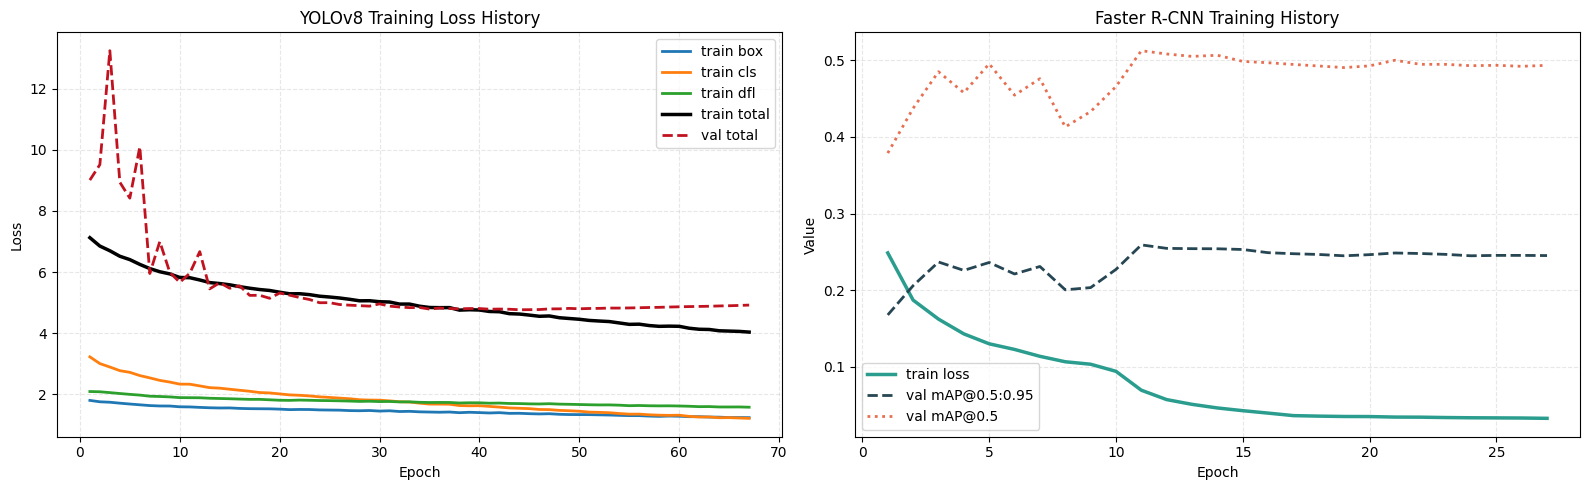

,model,artifact,best_mAP50_epoch,lowest_train_total_loss_epoch
0,YOLOv8,runs\detect\lesion_yolov8s_640_baseline\result...,63,67
1,Faster R-CNN,runs\frcnn\training_history.json,11,27


In [15]:
yolo_results_path = yolo_weights_path.parent.parent / "results.csv"
frcnn_history_path = frcnn_checkpoint_path.parent / "training_history.json"

yolo_loss_history = pd.read_csv(yolo_results_path)
yolo_loss_history["epoch_index"] = range(1, len(yolo_loss_history) + 1)
yolo_loss_history["train/total_loss"] = (
    yolo_loss_history["train/box_loss"]
    + yolo_loss_history["train/cls_loss"]
    + yolo_loss_history["train/dfl_loss"]
)
yolo_loss_history["val/total_loss"] = (
    yolo_loss_history["val/box_loss"]
    + yolo_loss_history["val/cls_loss"]
    + yolo_loss_history["val/dfl_loss"]
)

frcnn_history = pd.DataFrame(json.loads(frcnn_history_path.read_text(encoding="utf-8")))
frcnn_history["epoch_index"] = frcnn_history["epoch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/box_loss"], label="train box", linewidth=2)
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/cls_loss"], label="train cls", linewidth=2)
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/dfl_loss"], label="train dfl", linewidth=2)
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/total_loss"], label="train total", linewidth=2.5, color="black")
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["val/total_loss"], label="val total", linewidth=2, linestyle="--", color="#c1121f")
axes[0].set_title("YOLOv8 Training Loss History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].legend()

axes[1].plot(frcnn_history["epoch_index"], frcnn_history["train_loss"], label="train loss", linewidth=2.5, color="#2a9d8f")
axes[1].plot(frcnn_history["epoch_index"], frcnn_history["val_map"], label="val mAP@0.5:0.95", linewidth=2, linestyle="--", color="#264653")
axes[1].plot(frcnn_history["epoch_index"], frcnn_history["val_map50"], label="val mAP@0.5", linewidth=2, linestyle=":", color="#e76f51")
axes[1].set_title("Faster R-CNN Training History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value")
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].legend()

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        [
            {
                "model": "YOLOv8",
                "artifact": str(yolo_results_path.relative_to(PROJECT_ROOT)),
                "best_mAP50_epoch": int(yolo_loss_history["metrics/mAP50(B)"].idxmax()) + 1,
                "lowest_train_total_loss_epoch": int(yolo_loss_history["train/total_loss"].idxmin()) + 1,
            },
            {
                "model": "Faster R-CNN",
                "artifact": str(frcnn_history_path.relative_to(PROJECT_ROOT)),
                "best_mAP50_epoch": int(frcnn_history["val_map50"].idxmax()) + 1,
                "lowest_train_total_loss_epoch": int(frcnn_history["train_loss"].idxmin()) + 1,
            },
        ]
    )
)

In [16]:
requirements_packages = [line.strip() for line in (PROJECT_ROOT / "requirements.txt").read_text(encoding="utf-8").splitlines() if line.strip()]
requirements_names = [entry.split("==")[0] for entry in requirements_packages]

third_party_library_notes = {
    "asttokens": ("Notebook/runtime support", "Helps IPython format stack traces and executed code frames."),
    "certifi": ("HTTP/TLS", "Provides trusted CA certificates used by networking libraries such as Requests."),
    "charset-normalizer": ("HTTP/TLS", "Detects and normalizes text encodings for HTTP responses."),
    "colorama": ("Console output", "Improves colored terminal output on Windows shells."),
    "comm": ("Jupyter runtime", "Supports communication between the notebook kernel and front-end widgets."),
    "contourpy": ("Plotting dependency", "Backend used by Matplotlib for contour and filled contour drawing."),
    "cycler": ("Plotting dependency", "Supplies property cycling such as line-color rotation in Matplotlib."),
    "debugpy": ("Notebook/runtime support", "Lets Jupyter and VS Code attach Python debuggers."),
    "decorator": ("Notebook/runtime support", "Utility dependency used by IPython and other libraries."),
    "executing": ("Notebook/runtime support", "Helps IPython inspect the currently executing Python expression."),
    "faster-coco-eval": ("Detection evaluation", "Fast COCO-style evaluation backend for object-detection metrics."),
    "filelock": ("Utility", "Coordinates file locks used by model and dataset tooling."),
    "fonttools": ("Plotting dependency", "Font parsing and subsetting support for Matplotlib rendering."),
    "fsspec": ("Utility", "Unified filesystem interface used by ML/data tooling."),
    "idna": ("HTTP/TLS", "Internationalized domain-name handling for URL/network stacks."),
    "iniconfig": ("Testing", "Reads pytest configuration from ini-style files."),
    "ipykernel": ("Jupyter runtime", "Runs the Python kernel behind the notebooks."),
    "ipython": ("Jupyter runtime", "Interactive Python shell powering notebook execution experience."),
    "ipython_pygments_lexers": ("Jupyter runtime", "Syntax-highlighting helpers for IPython output."),
    "jedi": ("Notebook/runtime support", "Autocomplete and code-intelligence engine used by IPython."),
    "Jinja2": ("Templating", "General templating library used indirectly by some tools."),
    "jupyter_client": ("Jupyter runtime", "Kernel client APIs used to start and talk to notebook kernels."),
    "jupyter_core": ("Jupyter runtime", "Core paths and runtime utilities for Jupyter."),
    "kiwisolver": ("Plotting dependency", "Constraint solver used by Matplotlib layout logic."),
    "lightning-utilities": ("ML utilities", "Shared helper utilities required by TorchMetrics."),
    "MarkupSafe": ("Templating", "Safe string handling dependency for Jinja2."),
    "matplotlib": ("Visualization", "Creates the charts, bar plots, loss curves, and confusion matrices in the notebooks."),
    "matplotlib-inline": ("Jupyter runtime", "Displays Matplotlib figures inline inside notebook cells."),
    "mpmath": ("Math dependency", "Arbitrary-precision math used mainly through SymPy."),
    "nest-asyncio": ("Jupyter runtime", "Allows nested event loops so async code works inside notebooks."),
    "networkx": ("Graph/math dependency", "General graph library used indirectly by PyTorch and scientific tooling."),
    "numpy": ("Numerical computing", "Array math, confusion-matrix manipulation, and general numeric processing."),
    "opencv-python": ("Computer vision", "OpenCV bindings used for image/video processing tasks."),
    "packaging": ("Utility", "Version parsing and compatibility checks across the Python stack."),
    "pandas": ("Data analysis", "Builds tables, summaries, and CSV-backed DataFrames throughout the notebooks."),
    "parso": ("Notebook/runtime support", "Python parser used by Jedi for code completion."),
    "pillow": ("Imaging", "Loads images and draws boxes during visualization and dataset inspection."),
    "platformdirs": ("Utility", "Resolves user/cache/config directories for dependencies."),
    "pluggy": ("Testing", "Plugin system used by pytest."),
    "polars": ("Data analysis", "Alternative high-performance DataFrame library available in the environment."),
    "polars-runtime-32": ("Data analysis dependency", "Native runtime support package for Polars."),
    "prompt_toolkit": ("Jupyter runtime", "Interactive command-line editing used by IPython."),
    "psutil": ("System utilities", "System and process inspection helpers for notebook/runtime tooling."),
    "pure_eval": ("Notebook/runtime support", "Safe expression evaluation helper used by stack inspection tools."),
    "pycocotools": ("Detection evaluation", "COCO metric implementation used by object-detection evaluation libraries."),
    "Pygments": ("Jupyter runtime", "Syntax highlighting for code and notebook output."),
    "pyparsing": ("Plotting dependency", "Parsing helper used by Matplotlib and related tooling."),
    "pytest": ("Testing", "Runs the automated tests under the `tests/` directory."),
    "python-dateutil": ("Date/time utility", "Robust datetime parsing used by Pandas and Matplotlib."),
    "PyYAML": ("Configuration", "Reads and writes YAML dataset configuration files for YOLO workflows."),
    "pyzmq": ("Jupyter runtime", "Messaging transport used by Jupyter kernels."),
    "requests": ("HTTP client", "General HTTP library available for downloading or calling remote resources."),
    "scipy": ("Scientific computing", "General scientific algorithms available for analysis and metrics."),
    "setuptools": ("Packaging", "Python packaging/build support library."),
    "six": ("Compatibility", "Small Python 2/3 compatibility helper still required by some dependencies."),
    "stack-data": ("Notebook/runtime support", "Improves rich traceback rendering in IPython."),
    "sympy": ("Symbolic math", "Symbolic mathematics package available through the PyTorch stack."),
    "torch": ("Deep learning", "Core tensor, autograd, GPU, training, and inference library used by Faster R-CNN."),
    "torchmetrics": ("Metrics", "Computes detection metrics such as mAP for Faster R-CNN evaluation."),
    "torchvision": ("Computer vision / models", "Provides Faster R-CNN, transforms, datasets, and IoU box utilities."),
    "tornado": ("Jupyter runtime", "Async web/event-loop library used by Jupyter servers and kernels."),
    "traitlets": ("Jupyter runtime", "Configuration system used heavily across Jupyter components."),
    "typing_extensions": ("Typing support", "Backports newer typing features used by modern libraries."),
    "tzdata": ("Date/time utility", "Timezone database used when local timezone data is unavailable."),
    "ultralytics": ("Object detection", "Provides YOLOv8 training, validation, prediction, metrics, and saved training artifacts."),
    "ultralytics-thop": ("Model profiling", "Compute/FLOPs profiling dependency used by Ultralytics."),
    "urllib3": ("HTTP/TLS", "Low-level HTTP transport used by Requests."),
    "wcwidth": ("Console output", "Calculates printable character widths for interactive terminals."),
}

standard_library_notes = {
    "collections": "Uses counters and collection helpers for annotation and error summaries.",
    "csv": "Reads the project class-mapping CSV file and annotation metadata.",
    "dataclasses": "Defines small structured configuration and result containers in the project package.",
    "json": "Reads and writes checkpoints, notebook-style artifacts, and training-history files.",
    "math": "Provides numeric helper functions for dataset utilities.",
    "os": "Supports filesystem operations used by YOLO dataset materialization.",
    "pathlib": "Builds robust filesystem paths throughout the whole project.",
    "random": "Supports reproducible sampling and split generation.",
    "shutil": "Copies and organizes files while creating YOLO-compatible dataset folders.",
    "statistics": "Computes simple averages inside evaluation helpers.",
    "sys": "Adjusts import paths inside notebooks so the local package can be imported.",
    "typing": "Adds type hints for functions, records, and evaluation utilities.",
}

missing_packages = sorted(set(requirements_names) - set(third_party_library_notes))
if missing_packages:
    raise ValueError(f"Missing package explanations for: {missing_packages}")

third_party_rows = [
    {
        "library": package_name,
        "category": third_party_library_notes[package_name][0],
        "used_for": third_party_library_notes[package_name][1],
        "direct_project_use": package_name in {
            "matplotlib",
            "numpy",
            "opencv-python",
            "pandas",
            "pillow",
            "pycocotools",
            "PyYAML",
            "pytest",
            "torch",
            "torchmetrics",
            "torchvision",
            "ultralytics",
        },
    }
    for package_name in sorted(requirements_names, key=str.lower)
]

standard_rows = [
    {"library": module_name, "used_for": note}
    for module_name, note in sorted(standard_library_notes.items())
]

print("Third-party library reference from requirements.txt")
display(pd.DataFrame(third_party_rows))

print("Python standard-library modules imported directly in the project code")
display(pd.DataFrame(standard_rows))

Third-party library reference from requirements.txt


,library,category,used_for,direct_project_use
0,asttokens,Notebook/runtime support,Helps IPython format stack traces and executed...,False
1,certifi,HTTP/TLS,Provides trusted CA certificates used by netwo...,False
2,charset-normalizer,HTTP/TLS,Detects and normalizes text encodings for HTTP...,False
3,colorama,Console output,Improves colored terminal output on Windows sh...,False
4,comm,Jupyter runtime,Supports communication between the notebook ke...,False
...,...,...,...,...
63,tzdata,Date/time utility,Timezone database used when local timezone dat...,False
64,ultralytics,Object detection,"Provides YOLOv8 training, validation, predicti...",True
65,ultralytics-thop,Model profiling,Compute/FLOPs profiling dependency used by Ult...,False
66,urllib3,HTTP/TLS,Low-level HTTP transport used by Requests.,False


Python standard-library modules imported directly in the project code


,library,used_for
0,collections,Uses counters and collection helpers for annot...
1,csv,Reads the project class-mapping CSV file and a...
2,dataclasses,Defines small structured configuration and res...
3,json,"Reads and writes checkpoints, notebook-style a..."
4,math,Provides numeric helper functions for dataset ...
5,os,Supports filesystem operations used by YOLO da...
6,pathlib,Builds robust filesystem paths throughout the ...
7,random,Supports reproducible sampling and split gener...
8,shutil,Copies and organizes files while creating YOLO...
9,statistics,Computes simple averages inside evaluation hel...


## Model Evaluation Diagnostics

This section extends the dataset analysis with object-detection diagnostics for the trained **YOLOv8** and **Faster R-CNN** models on the shared **test split**.

It adds:

- object-level confusion matrices with a background row/column
- true positive, false positive, and false negative counts
- typical error breakdowns such as wrong-class matches, duplicate detections, localization misses, and missed ground-truth objects
- class-wise precision, recall, and F1 summaries
- training loss curves loaded from the saved YOLO and Faster R-CNN training artifacts

## Training Loss Curves

The next cell loads the saved training artifacts for both models:

- `runs/detect/.../results.csv` for YOLOv8
- `runs/frcnn/training_history.json` for Faster R-CNN

The YOLO plot includes the three saved training loss components and their summed total. The Faster R-CNN plot uses the epoch-level `train_loss` recorded during training.

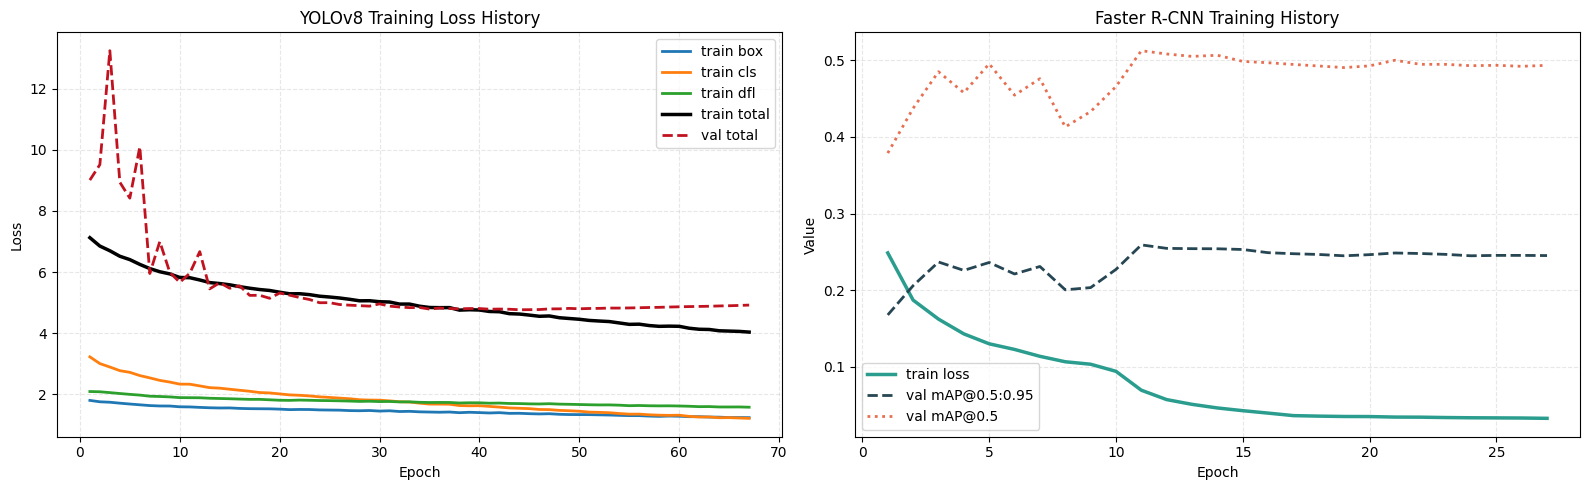

,model,artifact,best_mAP50_epoch,lowest_train_total_loss_epoch
0,YOLOv8,runs\detect\lesion_yolov8s_640_baseline\result...,63,67
1,Faster R-CNN,runs\frcnn\training_history.json,11,27


In [17]:
yolo_results_path = yolo_weights_path.parent.parent / "results.csv"
frcnn_history_path = frcnn_checkpoint_path.parent / "training_history.json"

yolo_loss_history = pd.read_csv(yolo_results_path)
yolo_loss_history["epoch_index"] = range(1, len(yolo_loss_history) + 1)
yolo_loss_history["train/total_loss"] = (
    yolo_loss_history["train/box_loss"]
    + yolo_loss_history["train/cls_loss"]
    + yolo_loss_history["train/dfl_loss"]
)
yolo_loss_history["val/total_loss"] = (
    yolo_loss_history["val/box_loss"]
    + yolo_loss_history["val/cls_loss"]
    + yolo_loss_history["val/dfl_loss"]
)

frcnn_history = pd.DataFrame(json.loads(frcnn_history_path.read_text(encoding="utf-8")))
frcnn_history["epoch_index"] = frcnn_history["epoch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/box_loss"], label="train box", linewidth=2)
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/cls_loss"], label="train cls", linewidth=2)
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/dfl_loss"], label="train dfl", linewidth=2)
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["train/total_loss"], label="train total", linewidth=2.5, color="black")
axes[0].plot(yolo_loss_history["epoch_index"], yolo_loss_history["val/total_loss"], label="val total", linewidth=2, linestyle="--", color="#c1121f")
axes[0].set_title("YOLOv8 Training Loss History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].legend()

axes[1].plot(frcnn_history["epoch_index"], frcnn_history["train_loss"], label="train loss", linewidth=2.5, color="#2a9d8f")
axes[1].plot(frcnn_history["epoch_index"], frcnn_history["val_map"], label="val mAP@0.5:0.95", linewidth=2, linestyle="--", color="#264653")
axes[1].plot(frcnn_history["epoch_index"], frcnn_history["val_map50"], label="val mAP@0.5", linewidth=2, linestyle=":", color="#e76f51")
axes[1].set_title("Faster R-CNN Training History")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Value")
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].legend()

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        [
            {
                "model": "YOLOv8",
                "artifact": str(yolo_results_path.relative_to(PROJECT_ROOT)),
                "best_mAP50_epoch": int(yolo_loss_history["metrics/mAP50(B)"].idxmax()) + 1,
                "lowest_train_total_loss_epoch": int(yolo_loss_history["train/total_loss"].idxmin()) + 1,
            },
            {
                "model": "Faster R-CNN",
                "artifact": str(frcnn_history_path.relative_to(PROJECT_ROOT)),
                "best_mAP50_epoch": int(frcnn_history["val_map50"].idxmax()) + 1,
                "lowest_train_total_loss_epoch": int(frcnn_history["train_loss"].idxmin()) + 1,
            },
        ]
    )
)